In [2]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
path = 'CC GENERAL.csv'
df = pd.read_csv(path)
df


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [3]:
df = df.drop(columns = 'CUST_ID', axis = 1)
df.fillna(df.median(), inplace=True)
df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,312.343947,0.000000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [4]:
print('Пропущенные значения:', df.isna().sum())
print('Дублируется:', df.duplicated().sum())

Пропущенные значения: BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64
Дублируется: 0


In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_data

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.3024    ,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.09749953,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.0932934 ,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.32687479,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.33830497,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.3243581 ,
        -0.52555097, -4.12276757]])

In [6]:
len(scaled_data)

8950

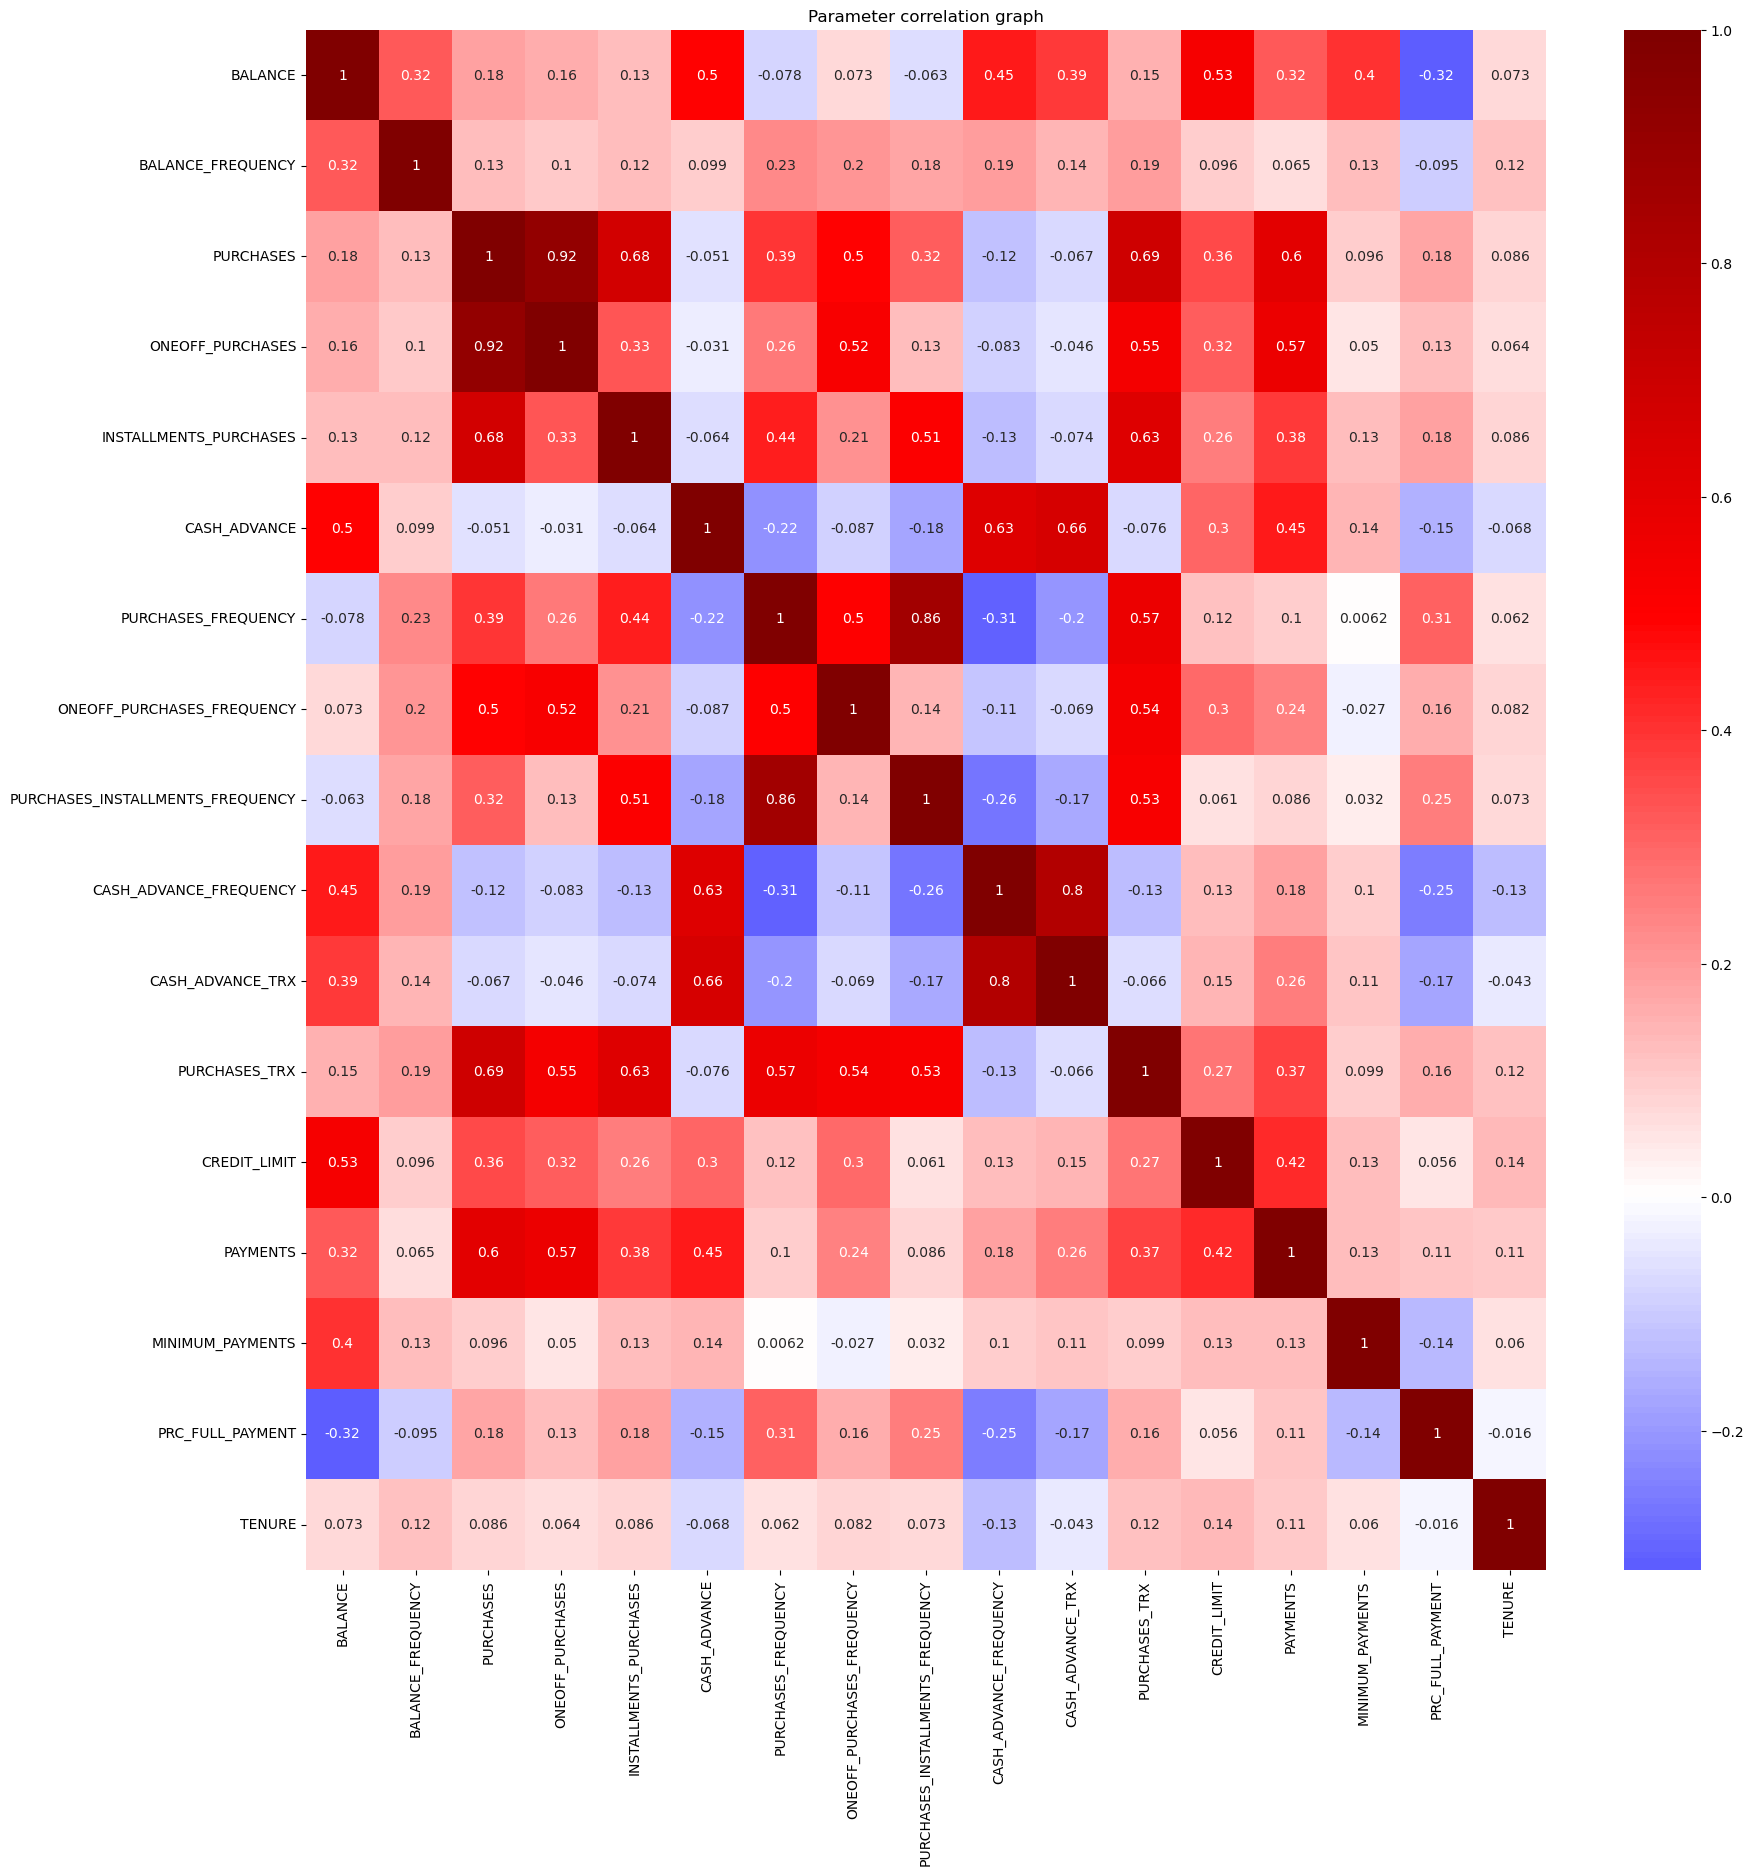

In [7]:
import seaborn as seaborn
plt.figure(figsize=(20, 20))
seaborn.heatmap(df.corr(), annot=True, cmap='seismic', center=0)
plt.title('Parameter correlation graph')
plt.show()

In [9]:
from sklearn.decomposition import PCA
X=scaled_data
pca = PCA(n_components=5)

X_transformed = pca.fit_transform(X)

In [10]:
X_transformed

array([[-1.68364879, -1.07224148],
       [-1.13408493,  2.50914981],
       [ 0.96939499, -0.3835769 ],
       ...,
       [-0.92898512, -1.80804835],
       [-2.33784475, -0.65361133],
       [-0.55802653, -0.4006461 ]])

In [19]:

from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings("ignore", category = UserWarning, message = "KMeans is known to have a memory leak on Windows with MKL")

arr_score = []

for i in range(2, 30):
    X = df.to_numpy()
    kmeans = KMeans(n_clusters = i, random_state = 0, n_init = "auto", max_iter = 500).fit(X)
    score = kmeans.inertia_
    arr_score.append(score)

In [20]:
from sklearn.metrics import silhouette_score
import warnings

In [21]:
n_cluster_list = []
silhouette_avg_list = []
for n_cluster in range(2,30):
    kmeans = KMeans(n_clusters=n_cluster, random_state=0, n_init="auto")
    kmeans.fit(X)
    cluster_labels = kmeans.predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    n_cluster_list.append(n_cluster)
    silhouette_avg_list.append(silhouette_avg)
    print(
        "For n_clusters =",
        n_cluster,
        "The average silhouette_score is :",
        silhouette_avg
    )

For n_clusters = 2 The average silhouette_score is : 0.5146077826818726
For n_clusters = 3 The average silhouette_score is : 0.4653064368093514
For n_clusters = 4 The average silhouette_score is : 0.39866115374987315
For n_clusters = 5 The average silhouette_score is : 0.40728790116981295
For n_clusters = 6 The average silhouette_score is : 0.414512592745958
For n_clusters = 7 The average silhouette_score is : 0.39030653843815916
For n_clusters = 8 The average silhouette_score is : 0.3830385418353255
For n_clusters = 9 The average silhouette_score is : 0.3888861589878479
For n_clusters = 10 The average silhouette_score is : 0.3848417457717622
For n_clusters = 11 The average silhouette_score is : 0.3345714898220394
For n_clusters = 12 The average silhouette_score is : 0.34042167100620047
For n_clusters = 13 The average silhouette_score is : 0.3321868613561743
For n_clusters = 14 The average silhouette_score is : 0.3206667928789645
For n_clusters = 15 The average silhouette_score is : 0.

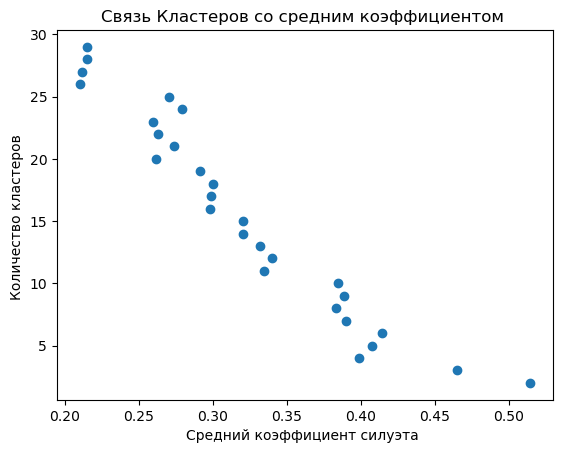

In [22]:
plt.scatter(x = silhouette_avg_list, y = n_cluster_list)
plt.xlabel('Cредний коэффициент силуэта ')
plt.ylabel('Количество кластеров ')
plt.title('Связь Кластеров со средним коэффициентом ')
plt.show()

Text(0.5, 1.0, 'Метод локтя')

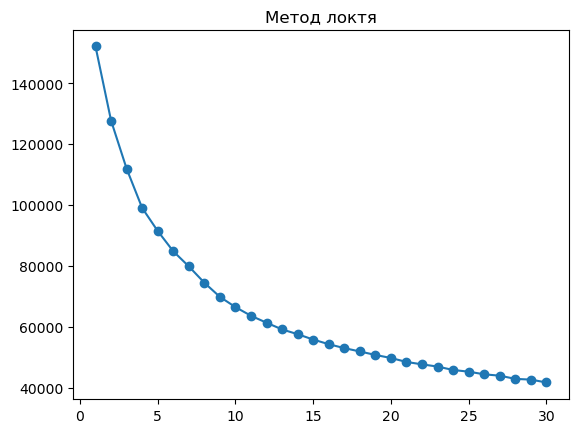

In [24]:
inertia = []
for k in range(1, 31):
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(scaled_data)
    inertia.append(kmeans_test.inertia_)

plt.plot(range(1, 31), inertia, marker='o')
plt.title('Метод локтя')

In [25]:
kmeans = KMeans(n_clusters = 7, random_state = 0, n_init = 10, max_iter = 500).fit(X)
arr_score.append(score)
kmeans.labels_

array([1, 0, 3, ..., 1, 1, 1], dtype=int32)

In [26]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_transformed)
df['Cluster'] = labels
counts = df['Cluster'].value_counts().sort_index()
percent = (df['Cluster'].value_counts(normalize=True).sort_index() * 100).round(1)
print("Распределение клиентов по группам:")
for i in range(len(counts)):
    print(f"Кластер {i}: {counts[i]} чел. ({percent[i]})")

Распределение клиентов по группам:
Кластер 0: 1454 чел. (16.2)
Кластер 1: 478 чел. (5.3)
Кластер 2: 1111 чел. (12.4)
Кластер 3: 682 чел. (7.6)
Кластер 4: 28 чел. (0.3)
Кластер 5: 2159 чел. (24.1)
Кластер 6: 650 чел. (7.3)
Кластер 7: 2085 чел. (23.3)
Кластер 8: 173 чел. (1.9)
Кластер 9: 130 чел. (1.5)


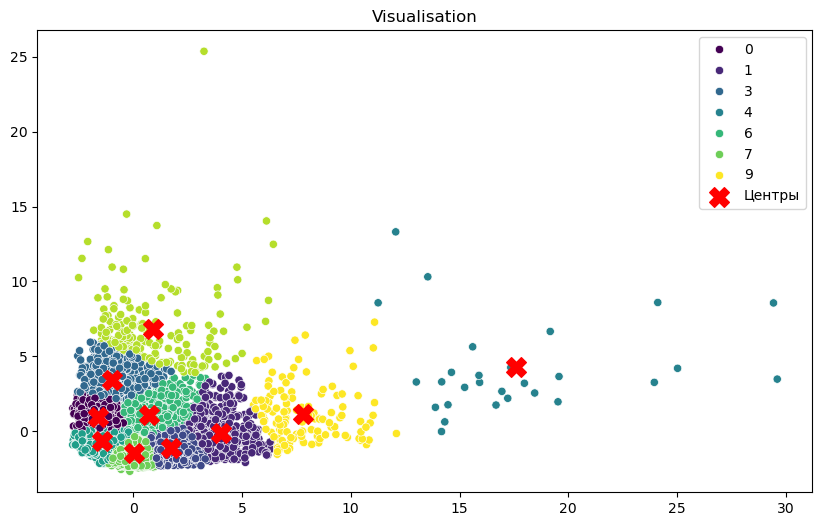

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_transformed[:, 0], y=X_transformed[:, 1], hue=labels, palette='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Центры')
plt.title('Visualisation')
plt.legend()
plt.show()

In [28]:
import numpy as np
from sklearn.cluster import cluster_optics_dbscan, compute_optics_graph

In [29]:
X = X_transformed
ordering, core_distances, reachability, predecessor = compute_optics_graph(
    X,
    min_samples=2,
    max_eps=np.inf,
    metric="minkowski",
    p=2,
    metric_params=None,
    algorithm="auto",
    leaf_size=30,
    n_jobs=None,
)
eps = 4.5
labels = cluster_optics_dbscan(
    reachability=reachability,
    core_distances=core_distances,
    ordering=ordering,
    eps=eps,
)
labels


array([0, 0, 0, ..., 0, 0, 0])

In [31]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_transformed)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = list(dbscan_labels).count(-1)
n_points_in_clusters = len(dbscan_labels) - n_noise_db

print(f"Количество: {n_clusters_db}")
print(f"Кол-во шумов: {n_noise_db}")

Количество: 5
Кол-во шумов: 134


In [32]:
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

digits = load_digits()
X, y = digits.data, digits.target
X.shape

(1797, 64)

C:\Users\user\AppData\Local\Temp\ipykernel_5820\905352962.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, edgecolors='k', cmap=plt.cm.get_cmap('jet', 10))


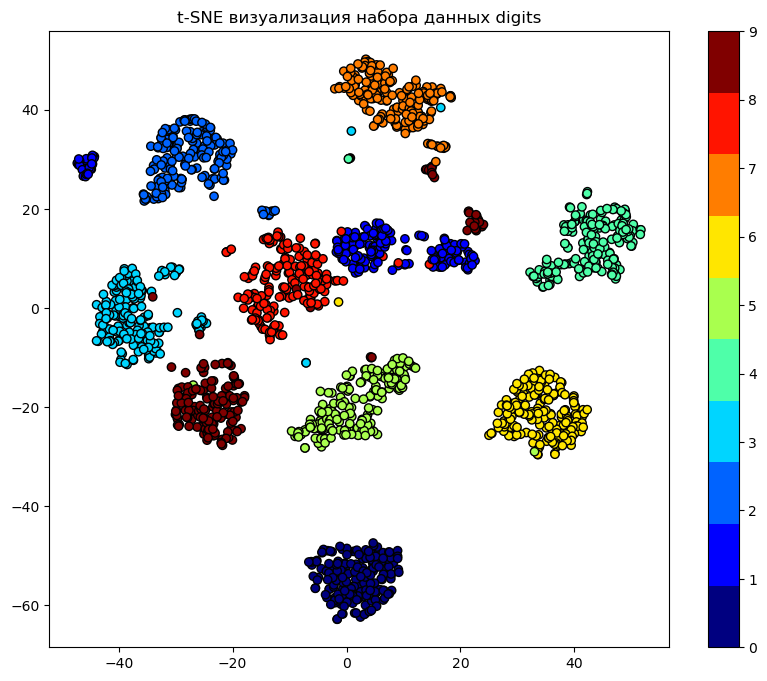

In [33]:
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

digits = load_digits()
X, y = digits.data, digits.target

X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, edgecolors='k', cmap=plt.cm.get_cmap('jet', 10))
plt.colorbar()
plt.title('t-SNE визуализация набора данных digits')
plt.show()
